# PRCP-1007-LiverPatientPred

# Liver Patient Prediction Using Machine Learning

This project focuses on analyzing patient data and using machine learning algorithms to predict whether a patient has liver disease.The project includes data analysis, exploratory data analysis, data preprocessing, feature engineering, implementation of multiple classification algorithms, model evaluation, model comparison, feature importance analysis, and identification of challenges faced during the modelling process.

**Domain:** Healthcare

# Executive Summary

**Goal:** Predict whether a patient has liver disease based on demographic information
and clinical laboratory measurements using machine learning classification techniques.

**Dataset:** The Indian Liver Patient Dataset contains 583 patient records, including
416 liver disease patients and 167 patients without liver disease. The dataset contains
clinical attributes such as age, gender, total bilirubin, direct bilirubin, alkaline
phosphotase, alamine aminotransferase, aspartate aminotransferase, total proteins,
albumin and albumin-globulin ratio.

**Data Analysis:** Exploratory data analysis will be performed to understand the
distribution of patients, relationships between clinical variables, missing values,
outliers and correlations between the features and the target variable.

**Machine Learning:** Multiple classification algorithms will be implemented and
compared, including Logistic Regression, Decision Tree, Random Forest, K-Nearest
Neighbors (KNN) and Support Vector Machine (SVM).

**Model Evaluation:** The models will be evaluated using accuracy, precision, recall,
F1-score and confusion matrix. Since this is a liver disease prediction problem,
recall will also be considered carefully because correctly identifying patients with
liver disease is an important part of the prediction task.

**Model Comparison:** The performance of all implemented algorithms will be compared
using the evaluation metrics. The final model will be selected based on the measured
performance and the objectives defined for the project.

**What drives the prediction:** Feature importance and model coefficients will be
analyzed to understand which patient characteristics and laboratory measurements
contribute most to the model's predictions.

**Challenges:** The project addresses issues such as missing values, different feature
scales, class imbalance and potential outliers. Appropriate preprocessing and
evaluation techniques will be applied to handle these challenges.

**How the model should be used:** The resulting model should be considered a machine
learning prediction tool for analysis and decision support, not as a replacement for
professional medical diagnosis.

**Project Deliverable:** The complete data analysis, preprocessing, model development,
model comparison, feature analysis and challenges will be presented in a single
Jupyter/Google Colab notebook.

# Contents

1. Problem Statement, Dataset Description and Feature Dictionary
2. Task 1: Data Analysis Report
   - Data Quality
   - Distributions
   - Outliers
   - Correlation Analysis
   - EDA Summary
3. Task 2: Model Creation and Model Comparison
   - Data Preprocessing
   - Classification Models
   - Model Evaluation
   - Feature Importance
   - Final Model Selection
4. Report on Challenges Faced
5. Task 3: Analysis of Model Design
6. Final Prediction
7. Limitations and Conclusion

# Problem Statement

Liver disease is an important healthcare concern. This project aims to analyze
patient data and develop machine learning models to predict whether a patient
has liver disease based on clinical and laboratory measurements.

# Dataset Description

The Indian Liver Patient Dataset contains patient demographic information and laboratory measurements related to liver function.
The dataset contains 583 patient records, including patients with liver disease and patients without liver disease.
The target variable represents the liver disease classification..

# Feature Description

The dataset contains 583 patients with 10 clinical features and one target
variable.

- `age` – Age of the patient.
- `gender` – Gender of the patient.
- `total_bilirubin` – Total bilirubin level.
- `direct_bilirubin` – Direct bilirubin level.
- `alkaline_phosphotase` – Alkaline phosphatase level.
- `alamine_aminotransferase` – ALT enzyme level.
- `aspartate_aminotransferase` – AST enzyme level.
- `total_proteins` – Total protein level.
- `albumin` – Albumin level.
- `albumin_and_globulin_ratio` – Ratio of albumin to globulin.
- `target` – Indicates whether the patient has liver disease or not.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

# Task 1: Complete Data Analysis Report

In [2]:
columns = [
    "Age",
    "Gender",
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "Alkaline_Phosphotase",
    "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase",
    "Total_Proteins",
    "Albumin",
    "Albumin_and_Globulin_Ratio",
    "Target"
]

df = pd.read_csv(r"C:\Users\Admin\Documents\Liver predicition.csv",
    header=None,
    names=columns
)

df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Target
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [3]:
df.shape

(583, 11)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    str    
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Proteins              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Target                      583 non-null    int64  
dtypes: float64(5), int64(5), str(1)
memory usage: 52.8 KB


In [5]:
df.describe()

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Target
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [6]:
df.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Proteins                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Target                        0
dtype: int64

In [7]:
df["Target"].value_counts()

Target
1    416
2    167
Name: count, dtype: int64

# Data Quality Observations

- The dataset contains **583 patient records**.
- There are **4 missing values** in `Albumin_and_Globulin_Ratio`.
- All other features have **no missing values**.
- The numerical features have different ranges and scales.
- Some laboratory measurements show **high maximum values**, indicating potential outliers.
- The target variable contains two classes: **1 (liver disease)** and **2 (no liver disease)**.

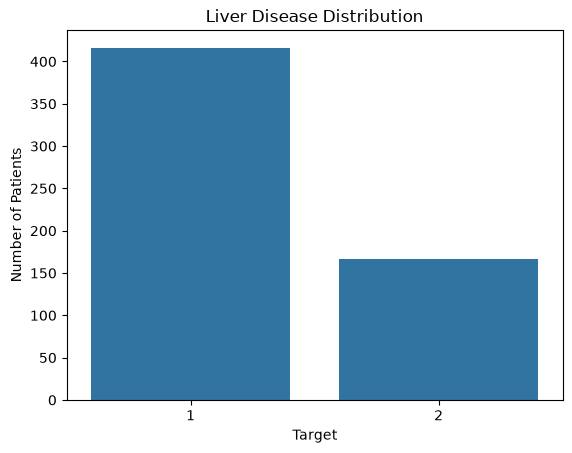

In [8]:
sns.countplot(x="Target",data=df)
plt.title("Liver Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Patients")
plt.show()

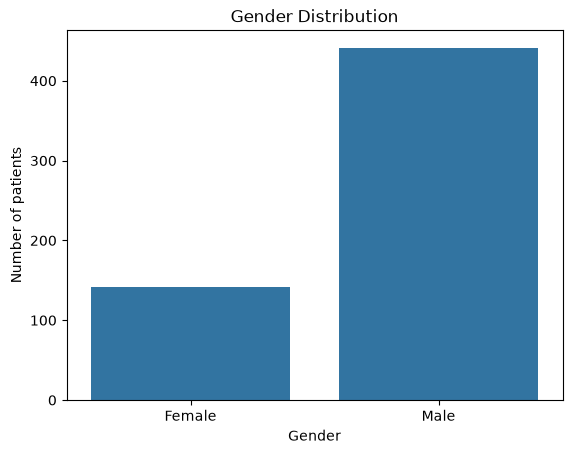

In [9]:
sns.countplot(x="Gender",data=df)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of patients")
plt.show()

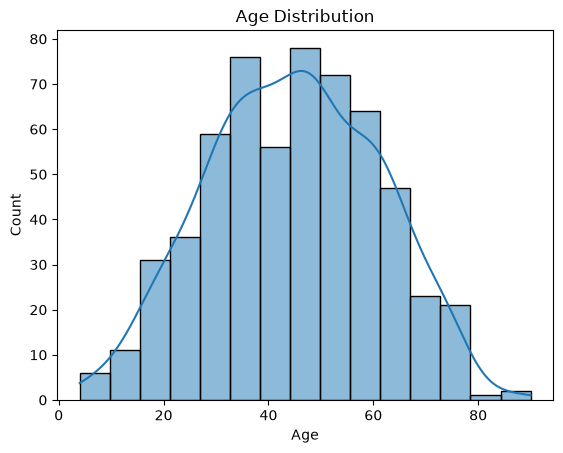

In [10]:
sns.histplot(df["Age"],kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

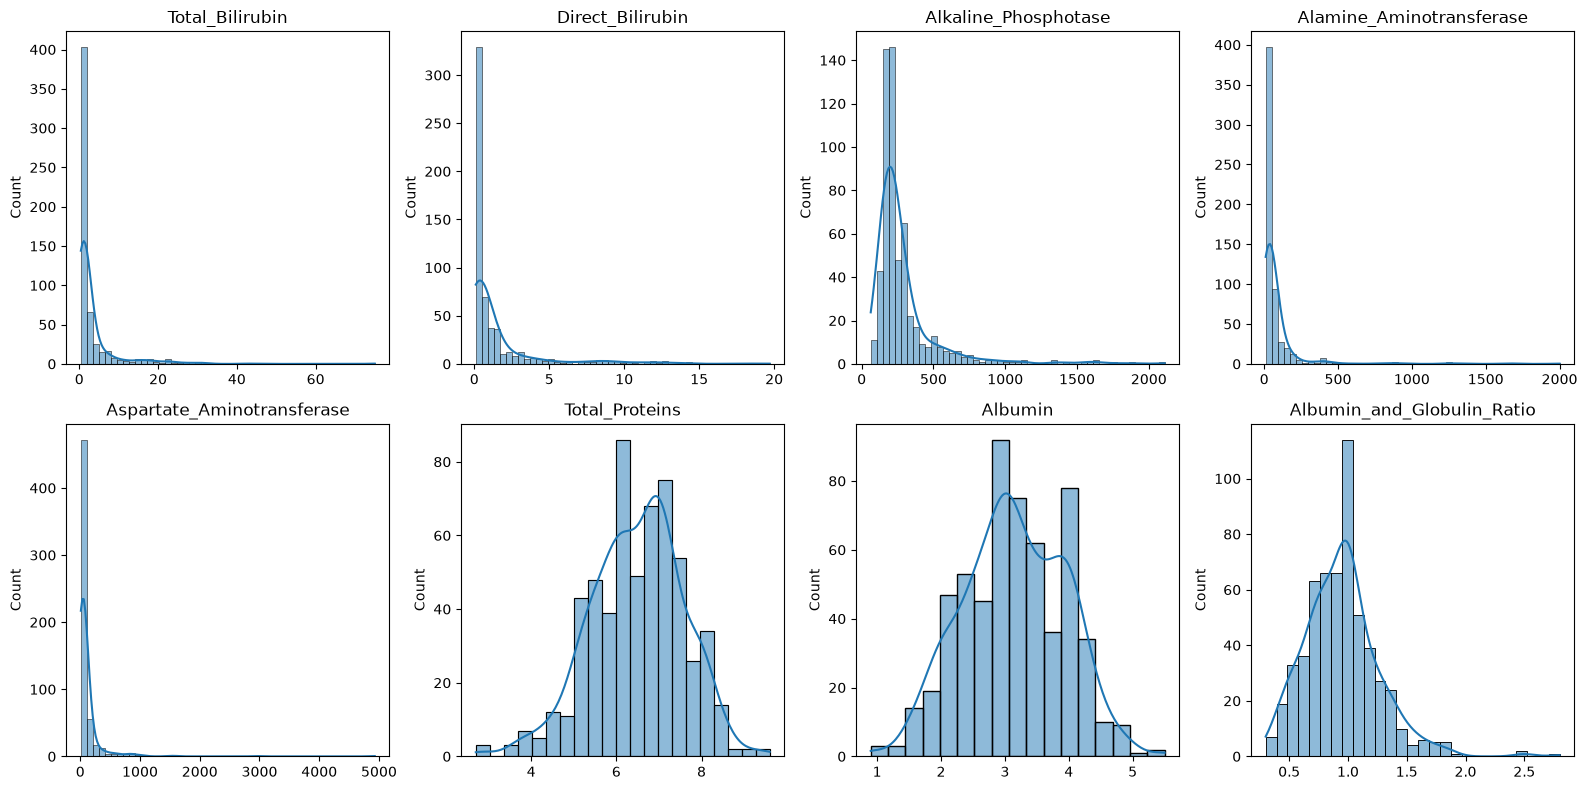

In [11]:
numeric_features = [
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "Alkaline_Phosphotase",
    "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase",
    "Total_Proteins",
    "Albumin",
    "Albumin_and_Globulin_Ratio"
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.histplot(df[feature], kde=True, ax=axes[i])
    axes[i].set_title(feature)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

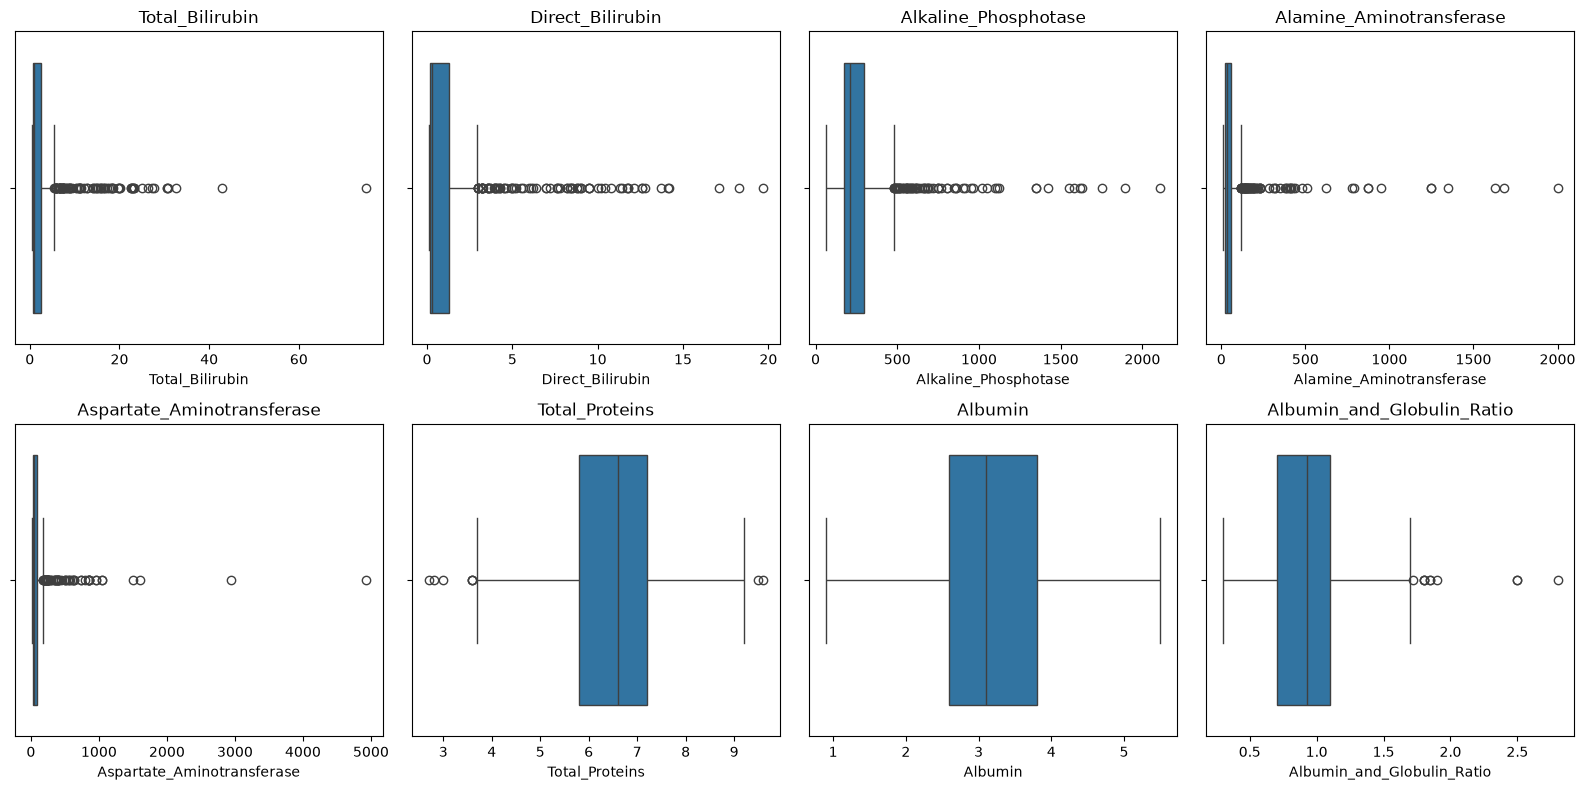

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.boxplot(x=df[feature], ax=axes[i])
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()

In [13]:
df["Gender"]=df["Gender"].astype(str).str.strip()
df["Gender"]=df["Gender"].replace({"Male":1,"Female":0})
df["Gender"]

0      0
1      1
2      1
3      1
4      1
      ..
578    1
579    1
580    1
581    1
582    1
Name: Gender, Length: 583, dtype: object

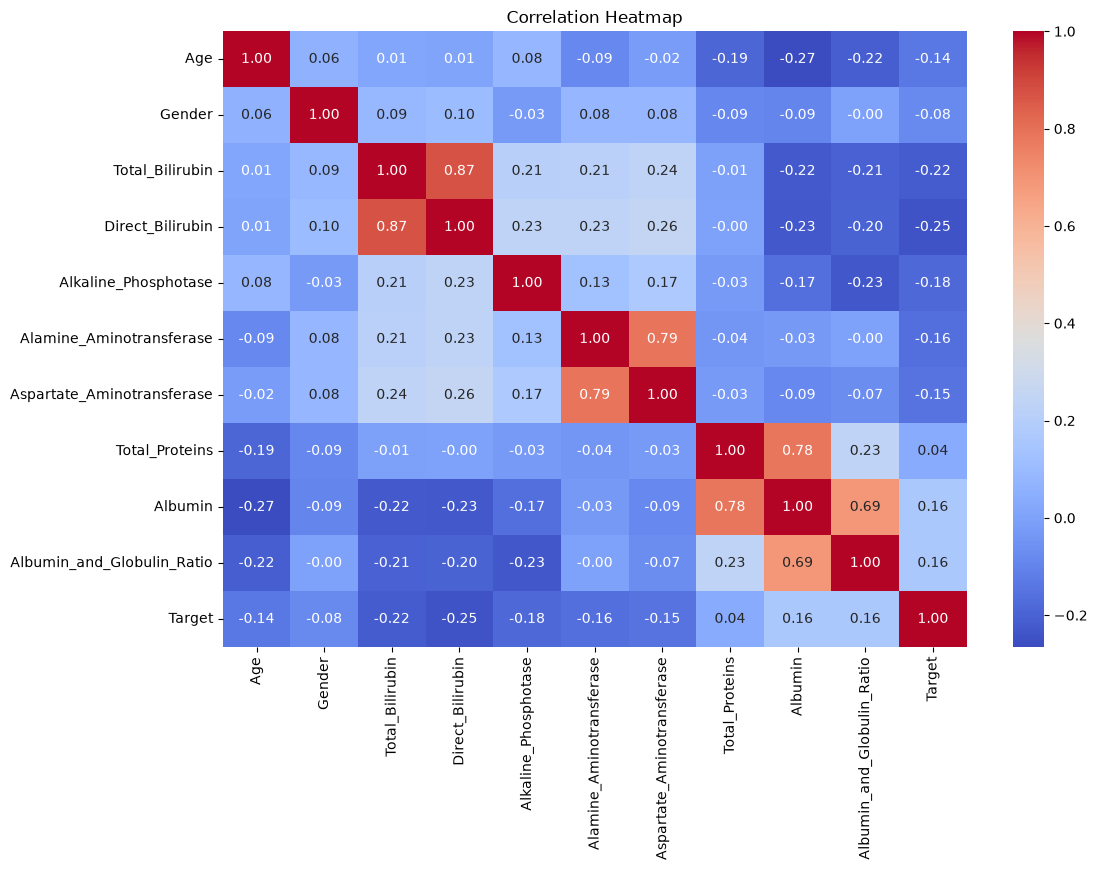

In [14]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# EDA Summary

### Categorical Signals

- Gender distribution was analyzed against the target variable to identify
  differences in liver disease occurrence between male and female patients.

### Numeric Signals

- Numerical laboratory features were analyzed using distributions,
  boxplots and correlation analysis.
- Bilirubin, enzyme levels and other liver-related measurements were
  examined for their relationship with the target variable.

### Weak or Unreliable Signals

- Features showing weak relationships with the target variable may provide
  limited predictive information when considered individually.
- Correlation alone should not be used to determine the importance of a
  feature.

### Outliers

- Several laboratory measurements contain potential outliers.
- These observations were identified using boxplots and will be considered
  during preprocessing.

### Skewness

- Some laboratory features show asymmetric distributions.
- Skewed features may require consideration during preprocessing and model
  development.

### Missing Values

- 4 missing values were identified in `Albumin_and_Globulin_Ratio`.
- These values will be handled during data preprocessing.

# Task 2: Machine Learning Model Creation.

The data is preprocessed and multiple classification algorithms are developed
to predict whether a patient has liver disease.

In [15]:
df["Albumin_and_Globulin_Ratio"] = df["Albumin_and_Globulin_Ratio"].fillna(
    df["Albumin_and_Globulin_Ratio"].median()
)
df.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Proteins                0
Albumin                       0
Albumin_and_Globulin_Ratio    0
Target                        0
dtype: int64

In [17]:
df["Gender"].value_counts()

Gender
1    441
0    142
Name: count, dtype: int64

In [18]:
X = df.drop("Target", axis=1)
y = df["Target"].map({1: 1, 2: 0})

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (583, 10)
Target shape: (583,)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (466, 10)
Testing data: (117, 10)


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")
print("Scaled training data:", X_train_scaled.shape)
print("Scaled testing data:", X_test_scaled.shape)

Feature scaling completed.
Scaled training data: (466, 10)
Scaled testing data: (117, 10)


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(probability=True, random_state=42)
}
for name, model in models.items():

    if name in ["Logistic Regression", "KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)

print("All models trained successfully.")

All models trained successfully.


In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for name, model in models.items():

    if name in ["Logistic Regression", "KNN", "SVM"]:
        predictions = model.predict(X_test_scaled)
        probabilities = model.predict_proba(X_test_scaled)[:, 1]
    else:
        predictions = model.predict(X_test)
        probabilities = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    })

results_df = pd.DataFrame(results)

results_df.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.735,0.741,0.964,0.838,0.831
1,Decision Tree,0.598,0.709,0.735,0.722,0.500
2,Random Forest,0.735,0.760,0.916,0.831,0.743
3,KNN,0.684,0.740,0.855,0.793,0.705
4,SVM,0.709,0.709,1.000,0.830,0.671


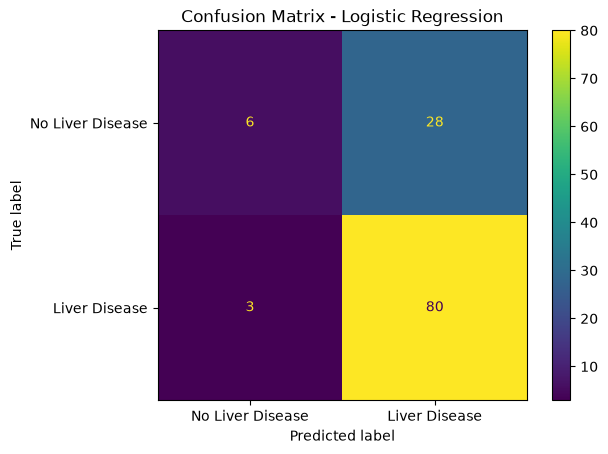

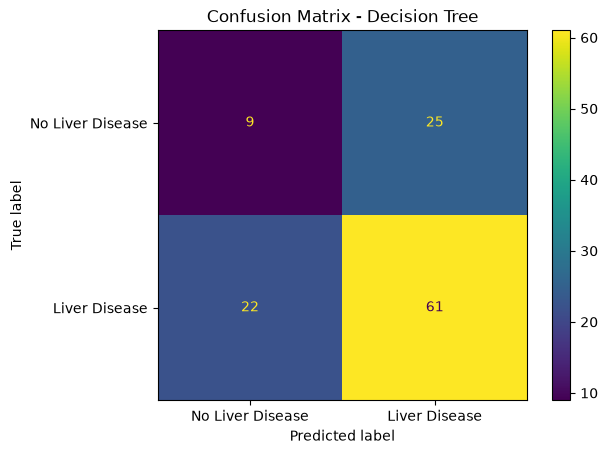

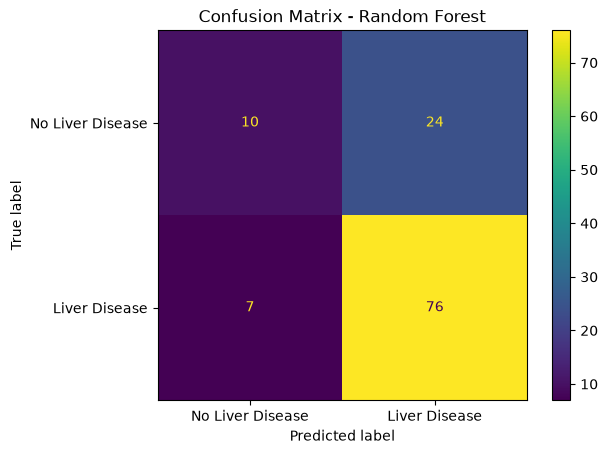

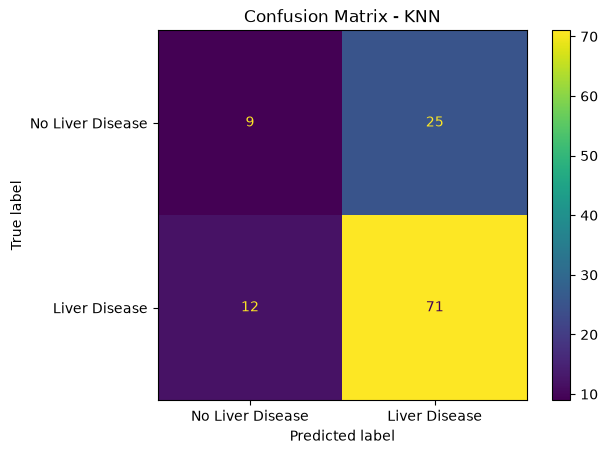

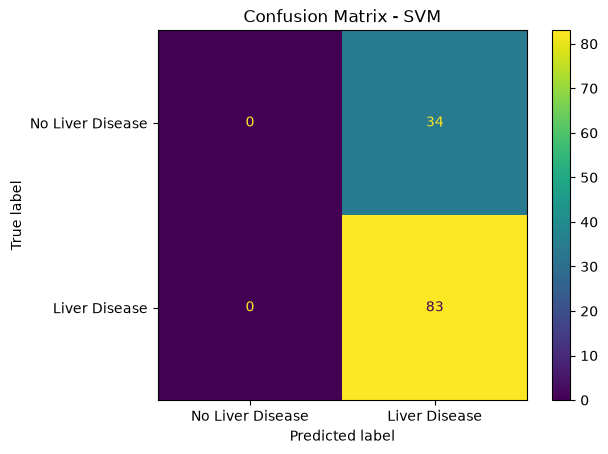

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for name, model in models.items():

    if name in ["Logistic Regression", "KNN", "SVM"]:
        predictions = model.predict(X_test_scaled)
    else:
        predictions = model.predict(X_test)

    cm = confusion_matrix(y_test, predictions)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Liver Disease", "Liver Disease"]
    )

    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

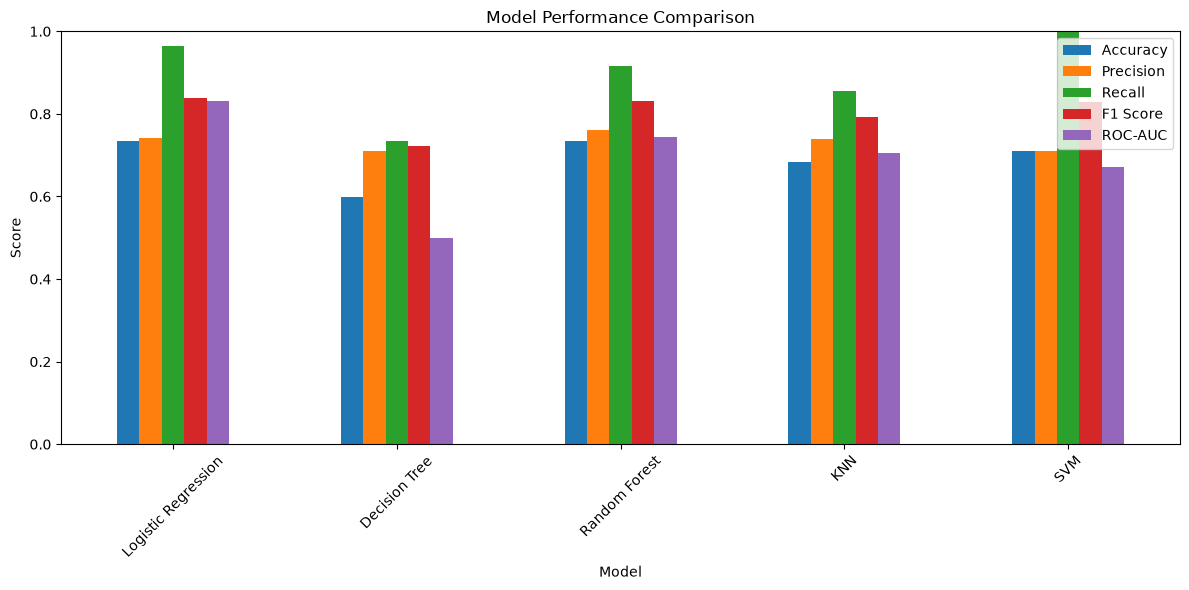

In [27]:
results_df.set_index("Model").plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
results_df.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.735,0.741,0.964,0.838,0.831
1,Decision Tree,0.598,0.709,0.735,0.722,0.500
2,Random Forest,0.735,0.760,0.916,0.831,0.743
3,KNN,0.684,0.740,0.855,0.793,0.705
4,SVM,0.709,0.709,1.000,0.830,0.671


In [29]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": models["Random Forest"].feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.round(3)

,Feature,Importance
4,Alkaline_Phosphotase,0.150
0,Age,0.134
6,Aspartate_Aminotransferase,0.131
5,Alamine_Aminotransferase,0.129
8,Albumin,0.100
2,Total_Bilirubin,0.098
7,Total_Proteins,0.092
9,Albumin_and_Globulin_Ratio,0.081
3,Direct_Bilirubin,0.067
1,Gender,0.018


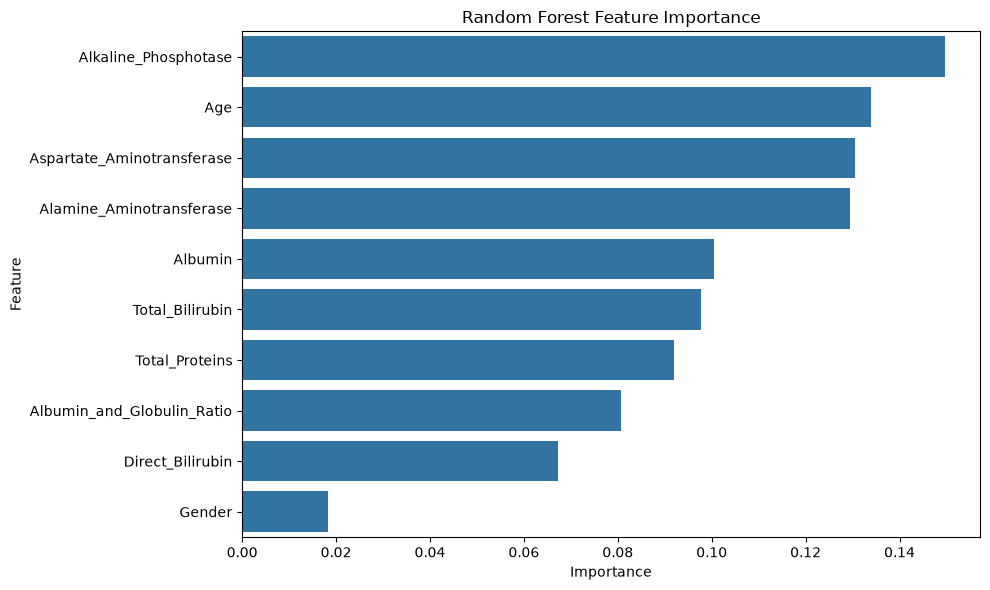

In [30]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [31]:
results_df.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.735,0.741,0.964,0.838,0.831
1,Decision Tree,0.598,0.709,0.735,0.722,0.500
2,Random Forest,0.735,0.760,0.916,0.831,0.743
3,KNN,0.684,0.740,0.855,0.793,0.705
4,SVM,0.709,0.709,1.000,0.830,0.671


In [32]:
best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(), "Model"
]

print("Selected Final Model:", best_model_name)

Selected Final Model: Logistic Regression


# Report on Challenges Faced

The following challenges were encountered during the project:

- Missing values were present in the `Albumin_and_Globulin_Ratio` feature.
- The target classes were not equally distributed.
- Numerical features had different ranges and scales.
- Some laboratory features contained potential outliers.
- The categorical `Gender` feature required encoding.
- Different classification models produced different results.
- Multiple evaluation metrics were required for model comparison.

# Task 3: Analysis of Model Design

The model was designed using patient demographic and laboratory information
as input features and liver disease status as the target variable.

The design was based on the following factors:

- **Input Features:** Age, Gender and laboratory measurements.
- **Target:** Liver disease classification.
- **Missing Value Treatment:** Median imputation was used for missing values.
- **Categorical Encoding:** Gender was converted into numerical values.
- **Feature Scaling:** StandardScaler was applied for scale-sensitive models.
- **Train-Test Split:** The data was divided into training and testing sets.
- **Classification Algorithms:** Logistic Regression, Decision Tree,
  Random Forest, KNN and SVM were used.
- **Evaluation:** Accuracy, Precision, Recall, F1-Score and ROC-AUC were used.
- **Final Model:** The model was selected based on the comparative evaluation
  results.

# Final Prediction

The selected final model is used to generate predictions for the test data.
The prediction indicates whether the patient is classified as having liver
disease or not.

In [33]:
# Get the selected model
final_model = models[best_model_name]

# Generate predictions
if best_model_name in ["Logistic Regression", "KNN", "SVM"]:
    final_predictions = final_model.predict(X_test_scaled)
else:
    final_predictions = final_model.predict(X_test)

print("Final Model:", best_model_name)
print("Predictions:", final_predictions[:10])

Final Model: Logistic Regression
Predictions: [1 1 1 1 1 1 1 1 1 1]


# Limitations

- The dataset contains a limited number of patient records.
- The target classes are imbalanced.
- The dataset contains only selected demographic and laboratory features.
- Model performance may vary with different train-test splits.
- The predictions should not be used as a replacement for professional
  medical diagnosis.

# Conclusion

This project analyzed the Indian Liver Patient Dataset and developed multiple
machine learning models for liver disease prediction.

The data was cleaned, explored and preprocessed before applying different
classification algorithms.

The models were evaluated using Accuracy, Precision, Recall, F1-Score and
ROC-AUC. Their performance was compared to identify a suitable final model.

Feature importance analysis was also performed to understand the contribution
of different patient attributes.

Overall, the project demonstrates an end-to-end machine learning workflow for
a healthcare classification problem.